# MLP Visualization

This notebook loads initial embeddings and embeddings compressed using MLP, then visualize it using t-SNE

## Load embedding vectors

Loading initial and compressed embeddings from chromadb

In [25]:
import os
import chromadb
import numpy as np

In [26]:
INITIAL_DB_PATH = "../../vector_chromadb/01_exp.db"
INITIAL_COLLECTION_NAME = "commit_embeddings"
PROCESSED_DB_PATH = "../../vector_chromadb/02_exp.db"
PROCESSED_COLLECTION_NAME = "commit_embeddings"
REPO_NAME = "hive"

In [27]:
print(f"Connecting to initial ChromaDB at '{INITIAL_DB_PATH}'.")
# Ensure the directory exists (important if this is the first time running ChromaDB here)
os.makedirs(INITIAL_DB_PATH, exist_ok=True)
initial_chroma_client = chromadb.PersistentClient(path=INITIAL_DB_PATH)
initial_collection = initial_chroma_client.get_collection(name=INITIAL_COLLECTION_NAME)
print(f"Connected to initial collection '{INITIAL_COLLECTION_NAME}'. Total items: {initial_collection.count()}")

print(f"Connecting to processed ChromaDB at '{PROCESSED_DB_PATH}'.")
os.makedirs(PROCESSED_DB_PATH, exist_ok=True)
processed_chroma_client = chromadb.PersistentClient(path=PROCESSED_DB_PATH)
# Use get_or_create_collection as the processed DB might be new or already exist
processed_collection = processed_chroma_client.get_or_create_collection(name=PROCESSED_COLLECTION_NAME)
print(f"Connected to processed collection '{PROCESSED_COLLECTION_NAME}'. Total items: {processed_collection.count()}")

Connecting to initial ChromaDB at '../../vector_chromadb/01_exp.db'.
Connected to initial collection 'commit_embeddings'. Total items: 16199
Connecting to processed ChromaDB at '../../vector_chromadb/02_exp.db'.
Connected to processed collection 'commit_embeddings'. Total items: 16199


### Get initial embeddings

In [28]:
filter_criteria = {"repo_name": REPO_NAME}

In [29]:
initial_results = initial_collection.get(
        where=filter_criteria,
        include=['embeddings', 'metadatas', 'documents']
    )


In [30]:
initial_embeddings = initial_results['embeddings']

initial_embeddings.shape

(16199, 768)

In [31]:
initial_all_labels = []
if initial_results and initial_results['metadatas']:
        print(f"Processing metadata for {len(initial_results['metadatas'])} items...")
        for i, metadata_dict in enumerate(initial_results['metadatas']):
            if 'label' in metadata_dict:
                initial_all_labels.append(metadata_dict['label'])

len(initial_all_labels)

Processing metadata for 16199 items...


16199

### Get processed embeddings

In [32]:
processed_results = processed_collection.get(
        where=filter_criteria,
        include=['embeddings', 'metadatas', 'documents']
    )

In [33]:
processed_embeddings = processed_results['embeddings']

processed_embeddings.shape

(16199, 64)

In [34]:
processed_all_labels = []
if processed_results and processed_results['metadatas']:
        print(f"Processing metadata for {len(processed_results['metadatas'])} items...")
        for i, metadata_dict in enumerate(processed_results['metadatas']):
            if 'label' in metadata_dict:
                processed_all_labels.append(metadata_dict['label'])

len(processed_all_labels)

Processing metadata for 16199 items...


16199

## Visualization using t-SNE

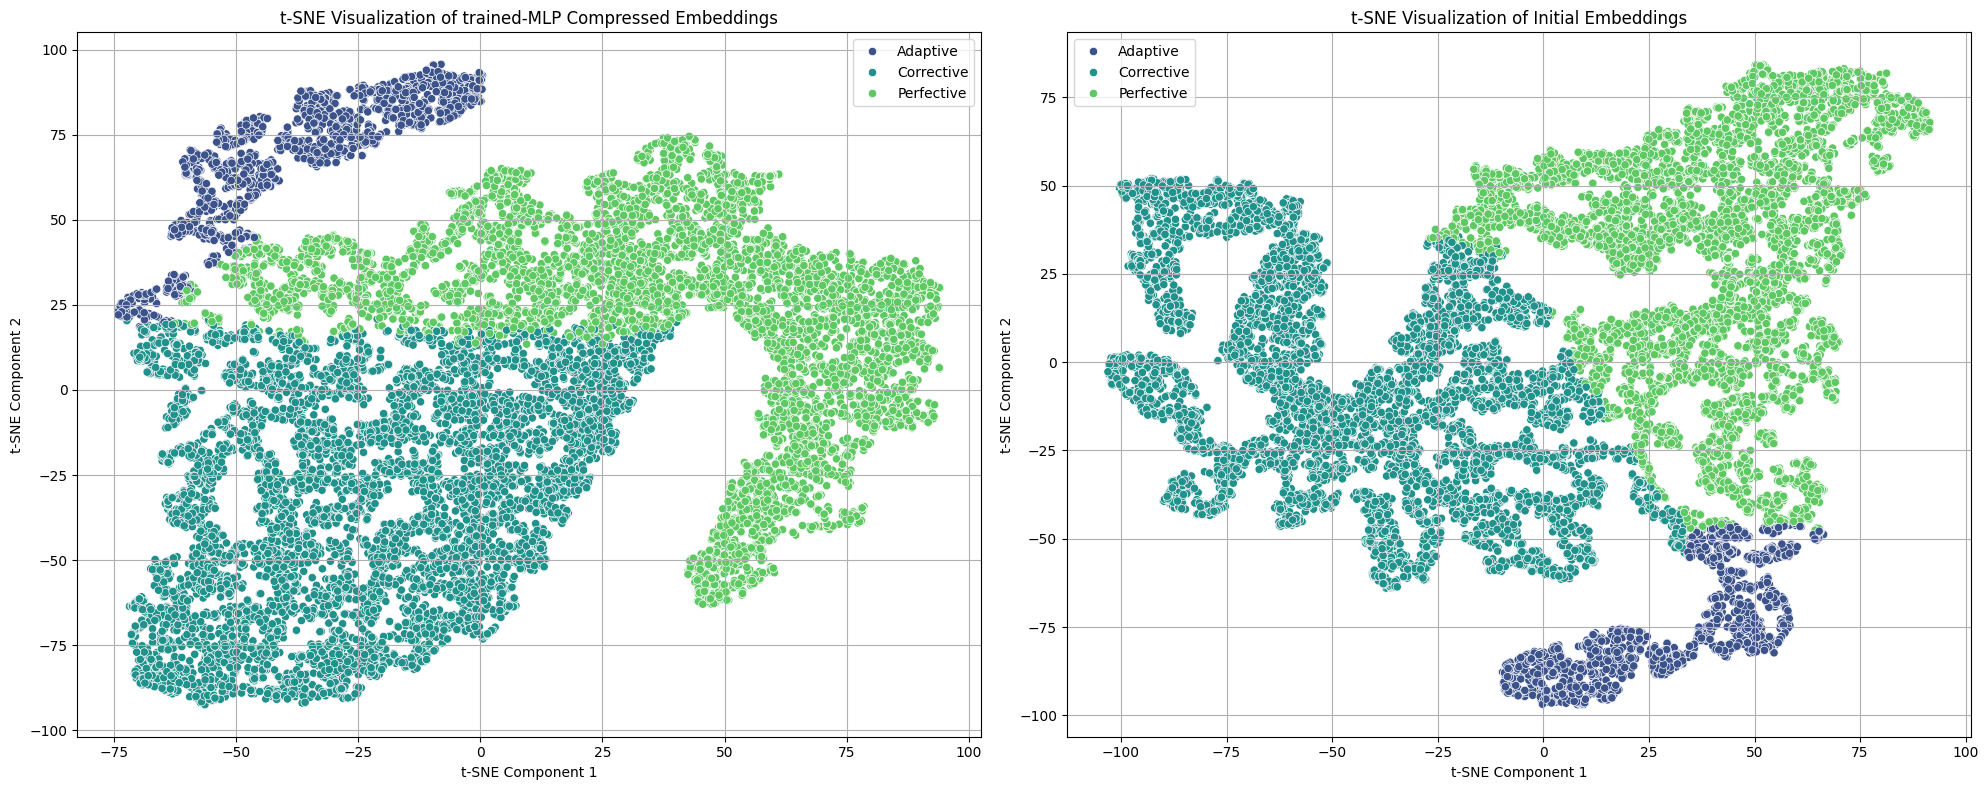

In [36]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Reduce the dimensions of the compressed embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(processed_embeddings)

# Plot compressed embeddings
sns.scatterplot(x=embeddings_2d[:, 0], 
                y=embeddings_2d[:, 1], 
                palette='viridis',
                hue=initial_all_labels,
                ax=ax1)
ax1.set_title('t-SNE Visualization of trained-MLP Compressed Embeddings')
ax1.set_xlabel('t-SNE Component 1')
ax1.set_ylabel('t-SNE Component 2')
ax1.grid(True)

# Plot initial embeddings
initial_tsne = TSNE(n_components=2, random_state=42)
initial_embeddings_2d = initial_tsne.fit_transform(initial_embeddings)

sns.scatterplot(x=initial_embeddings_2d[:, 0], 
                y=initial_embeddings_2d[:, 1], 
                palette='viridis',
                hue=processed_all_labels,
                ax=ax2)
ax2.set_title('t-SNE Visualization of Initial Embeddings')
ax2.set_xlabel('t-SNE Component 1')
ax2.set_ylabel('t-SNE Component 2')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Visualization using UMAP


In [9]:
import umap
reducer = umap.UMAP()
reduced_compressed_embeddings = reducer.fit_transform(compressed_embeddings_np)
reduced_initial_embeddings = reducer.fit_transform(embeddings_tensor)

/Users/savirarama/Documents/Embedding-Clustering-Visualization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/savirarama/Documents/Embedding-Clustering-Visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/savirarama/Documents/Embedding-Clustering-Visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
